<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import matplotlib.pyplot as plt



In [19]:
df = pd.read_csv("aalkafou_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,knygren_glmbayes,00072e026eadd6ffc3482d026f501f92577bbcd1,Nygren <Kjell.Nygren@sanofi.com>,1596427257,Finished most cleanup for the new rIndependent...,2020-08
1,knygren_glmbayes,00489b17e85cab12b6a3624ed9ac3df8c202e1e1,knygren <kjell.a.nygren@gmail.com>,1752529616,Add Initial News.MD for version tracking\n,2025-07
2,knygren_glmbayes,0096d32f114cc9233dd817f1df47343073340294,knygren <kjell.a.nygren@gmail.com>,1757498572,Adding Rdpack capabilities to ensure enabled b...,2025-09
3,knygren_glmbayes,0102d1080849964f0ee67b9815bffbef1ad34b02,knygren <kjell.a.nygren@gmail.com>,1753958575,Adds PKG_CPP_FLAGS to configure script output.\n,2025-07
4,knygren_glmbayes,0269eb3d3172fe0038f54f249148737b2c75ecb2,knygren <kjell.a.nygren@gmail.com>,1753981278,Additional edits to configure script\n,2025-07


In [20]:
prj = 'knygren_glmbayes'

df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')


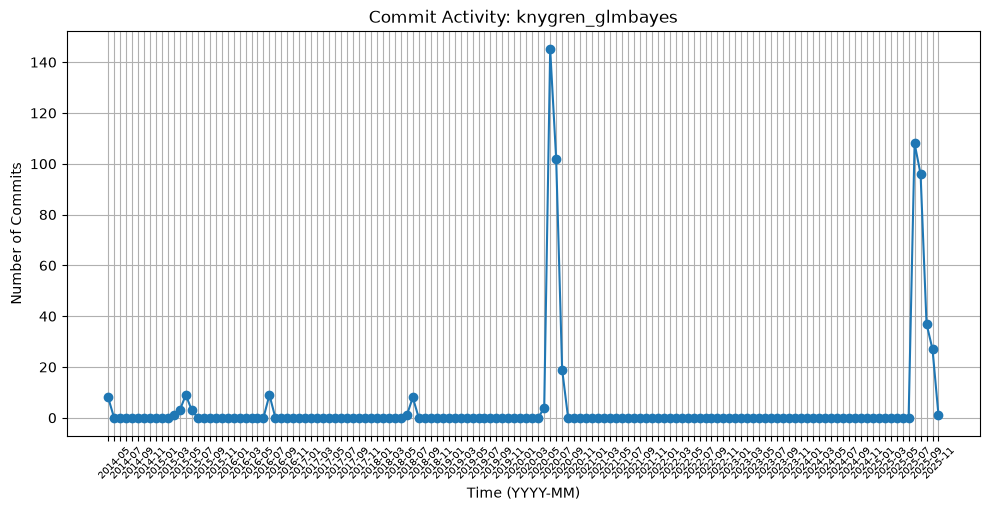

In [21]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("aalkafou_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

In [22]:
# Find the longest continuous inactivity gap (zero-commit months)

zero_months = monthly_counts[monthly_counts['Commits'] == 0].copy()

groups = (zero_months.index.to_series().diff() != 1).cumsum()
gaps = zero_months.groupby(groups)

longest_gap = max(gaps, key=lambda x: len(x[1]))[1]

gap_start = longest_gap['Month'].iloc[0]
gap_end = longest_gap['Month'].iloc[-1]
gap_length = len(longest_gap)

print("Longest Gap Start:", gap_start)
print("Longest Gap End:", gap_end)
print("Longest Gap Length:", gap_length, "months")

Longest Gap Start: 2020-09
Longest Gap End: 2025-06
Longest Gap Length: 58 months


In [46]:
projects = [
    'knygren_glmbayes',
    'rapidsai_cuxfilter',
    'nfft_nfft',
    'cselab_aphros',
    'learning-at-home_hivemind',
    'epics-base_pva2pva',
    'geos-esm_mapl',
    'icbi-lab_luca',
    'ajdawson_windspharm',
    'sonvt1710_deepface'
]

print("Number of projects:", len(projects))

Number of projects: 10
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Monthly Commit Time Series

For each project, commit activity is grouped by month. Missing months between the first and last commit are explicitly included with zero commits.

In [47]:
import os

os.makedirs("part2_timeseries_plots", exist_ok=True)

In [50]:
os.makedirs("part2_timeseries_csv", exist_ok=True)

monthly_data = {}

for prj in projects:
    df1 = df[df['project'] == prj]

    monthly_counts = (
        df1.groupby('Month')
        .size()
        .reset_index(name='#Commits')
    )

    monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])

    full_date_range = pd.DataFrame({
        'time': pd.date_range(
            start=monthly_counts['time'].min(),
            end=monthly_counts['time'].max(),
            freq='MS'
        )
    })

    monthly_counts = pd.merge(
        full_date_range,
        monthly_counts,
        on='time',
        how='left'
    )

    monthly_counts['#Commits'] = (
        monthly_counts['#Commits']
        .fillna(0)
        .astype(int)
    )

    monthly_counts['Month'] = (
        monthly_counts['time']
        .dt.strftime('%Y-%m')
    )

    monthly_counts = monthly_counts[['Month', '#Commits']]

    monthly_data[prj] = monthly_counts

    monthly_counts.to_csv(
        f"part2_timeseries_csv/aalkafou_commits_timeseries_{prj}.csv",
        sep=";",
        index=False
    )

    print(prj, ":", len(monthly_counts), "months")

knygren_glmbayes : 140 months
rapidsai_cuxfilter : 90 months
nfft_nfft : 248 months
cselab_aphros : 93 months
learning-at-home_hivemind : 68 months
epics-base_pva2pva : 119 months
geos-esm_mapl : 83 months
icbi-lab_luca : 52 months
ajdawson_windspharm : 161 months
sonvt1710_deepface : 69 months


In [51]:
os.makedirs("part2_timeseries_plots", exist_ok=True)

for prj in projects:
    monthly_counts = monthly_data[prj]

    plt.figure(figsize=(12, 5))

    plt.plot(
        monthly_counts['Month'],
        monthly_counts['#Commits'],
        linestyle='-'
    )

    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(prj)
    plt.grid(True)

    step = max(1, len(monthly_counts) // 12)
    plt.xticks(
        range(0, len(monthly_counts), step),
        monthly_counts['Month'].iloc[::step],
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        f"part2_timeseries_plots/aalkafou_timeseries_{prj}.png",
        dpi=600
    )

    plt.close()

    print("Saved:", prj)

Saved: knygren_glmbayes
Saved: rapidsai_cuxfilter
Saved: nfft_nfft
Saved: cselab_aphros
Saved: learning-at-home_hivemind
Saved: epics-base_pva2pva
Saved: geos-esm_mapl
Saved: icbi-lab_luca
Saved: ajdawson_windspharm
Saved: sonvt1710_deepface


## Identify the Longest Inactivity Gap

The longest inactivity gap was calculated separately for each of the 10 assigned projects. The results, including the gap start month, end month, duration, number of commits after the gap, and number of inactivity gaps lasting at least three months, are recorded in `aalkafou_project_stats.csv`.

## Inactivity Gap Analysis

For each project, the following analysis identifies the longest continuous period of zero commits, the number of commits after the longest gap, and the number of inactivity gaps lasting at least three months.

In [52]:
gap_results = []

for prj in projects:
    monthly_counts = monthly_data[prj].copy()

    zero_months = monthly_counts[
        monthly_counts['#Commits'] == 0
    ].copy()

    if len(zero_months) > 0:

        groups = (
            zero_months.index.to_series().diff() != 1
        ).cumsum()

        gaps = [
            group
            for _, group in zero_months.groupby(groups)
        ]

        longest_gap = max(gaps, key=len)

        longest_gap_start = longest_gap['Month'].iloc[0]
        longest_gap_end = longest_gap['Month'].iloc[-1]
        longest_gap_length = len(longest_gap)

        gap_end_index = longest_gap.index[-1]

        commits_after_gap = int(
            monthly_counts.loc[
                monthly_counts.index > gap_end_index,
                '#Commits'
            ].sum()
        )

        num_gaps = sum(
            len(gap) >= 3
            for gap in gaps
        )

    else:
        longest_gap_start = 'N/A'
        longest_gap_end = 'N/A'
        longest_gap_length = 0
        commits_after_gap = 0
        num_gaps = 0

    gap_results.append({
        'project': prj,
        'LongestGapStart': longest_gap_start,
        'LongestGapEnd': longest_gap_end,
        'LongestGapLength': longest_gap_length,
        'NumCommitsAfterLastGap': commits_after_gap,
        'NumberOfGapsInTimeline': num_gaps
    })

gap_df = pd.DataFrame(gap_results)

gap_df

,project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,knygren_glmbayes,2020-09,2025-06,58,269,5
1,rapidsai_cuxfilter,2019-01,2019-01,1,2426,0
2,nfft_nfft,2023-03,2024-03,13,129,10
3,cselab_aphros,2024-08,2025-03,8,2,3
4,learning-at-home_hivemind,2024-04,2024-04,1,372,0
5,epics-base_pva2pva,2023-04,2023-11,8,28,8
6,geos-esm_mapl,N/A,N/A,0,0,0
7,icbi-lab_luca,2023-12,2024-11,12,5,2
8,ajdawson_windspharm,2018-09,2021-01,29,45,13
9,sonvt1710_deepface,2020-10,2020-10,1,1703,0


In [53]:
activity_patterns = {
    'knygren_glmbayes': 'irregular',
    'rapidsai_cuxfilter': 'irregular',
    'nfft_nfft': 'declining',
    'cselab_aphros': 'declining',
    'learning-at-home_hivemind': 'declining',
    'epics-base_pva2pva': 'declining',
    'geos-esm_mapl': 'rising',
    'icbi-lab_luca': 'declining',
    'ajdawson_windspharm': 'declining',
    'sonvt1710_deepface': 'irregular'
}

gap_df['ActivityPattern'] = (
    gap_df['project']
    .map(activity_patterns)
)

gap_df

,project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,knygren_glmbayes,2020-09,2025-06,58,269,5,irregular
1,rapidsai_cuxfilter,2019-01,2019-01,1,2426,0,irregular
2,nfft_nfft,2023-03,2024-03,13,129,10,declining
3,cselab_aphros,2024-08,2025-03,8,2,3,declining
4,learning-at-home_hivemind,2024-04,2024-04,1,372,0,declining
5,epics-base_pva2pva,2023-04,2023-11,8,28,8,declining
6,geos-esm_mapl,N/A,N/A,0,0,0,rising
7,icbi-lab_luca,2023-12,2024-11,12,5,2,declining
8,ajdawson_windspharm,2018-09,2021-01,29,45,13,declining
9,sonvt1710_deepface,2020-10,2020-10,1,1703,0,irregular


## Project Summary Statistics

The Part 1 project statistics and GitHub information are combined with the Part 2 inactivity-gap and activity-pattern results.

In [54]:
part1_stats = (
    df.groupby('project')
    .agg(
        ncommits=('commit', 'count'),
        nauthors=('author', 'nunique'),
        from_time=('time', 'min'),
        to_time=('time', 'max')
    )
    .reset_index()
)

part1_stats['from'] = (
    pd.to_datetime(part1_stats['from_time'], unit='s')
    .dt.strftime('%Y-%m-%d')
)

part1_stats['to'] = (
    pd.to_datetime(part1_stats['to_time'], unit='s')
    .dt.strftime('%Y-%m-%d')
)

part1_stats = part1_stats.drop(
    columns=['from_time', 'to_time']
)

part1_stats

,project,ncommits,nauthors,from,to
0,ajdawson_windspharm,366,23,2012-06-16,2025-10-01
1,cselab_aphros,10702,8,2017-11-28,2025-07-20
2,epics-base_pva2pva,660,19,2015-09-04,2025-07-28
3,geos-esm_mapl,14975,99,2019-06-07,2026-04-16
4,icbi-lab_luca,578,8,2020-10-29,2025-01-19
5,knygren_glmbayes,581,7,2014-04-05,2025-11-03
6,learning-at-home_hivemind,6394,89,2020-03-01,2025-10-14
7,nfft_nfft,3965,55,2005-04-13,2025-11-01
8,rapidsai_cuxfilter,2688,76,2018-06-14,2025-11-05
9,sonvt1710_deepface,2071,110,2020-02-08,2025-10-21


In [55]:
github_info = {
    'knygren_glmbayes': [5, 1, '2026-09-27'],
    'rapidsai_cuxfilter': [313, 81, '2026-06-22'],
    'nfft_nfft': [188, 51, '2026-09-28'],
    'cselab_aphros': [460, 52, '2025-07-20'],
    'learning-at-home_hivemind': [2529, 233, '2026-01-04'],
    'epics-base_pva2pva': [5, 15, '2026-08-02'],
    'geos-esm_mapl': [45, 25, '2026-09-23'],
    'icbi-lab_luca': [94, 30, '2025-01-19'],
    'ajdawson_windspharm': [100, 39, '2026-08-25'],
    'sonvt1710_deepface': [0, 0, '2026-09-28']
}

part1_stats['nstars'] = part1_stats['project'].map(
    lambda x: github_info[x][0]
)

part1_stats['nforks'] = part1_stats['project'].map(
    lambda x: github_info[x][1]
)

part1_stats['lastGHCommitDate'] = part1_stats['project'].map(
    lambda x: github_info[x][2]
)

part1_stats

,project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate
0,ajdawson_windspharm,366,23,2012-06-16,2025-10-01,100,39,2026-08-25
1,cselab_aphros,10702,8,2017-11-28,2025-07-20,460,52,2025-07-20
2,epics-base_pva2pva,660,19,2015-09-04,2025-07-28,5,15,2026-08-02
3,geos-esm_mapl,14975,99,2019-06-07,2026-04-16,45,25,2026-09-23
4,icbi-lab_luca,578,8,2020-10-29,2025-01-19,94,30,2025-01-19
5,knygren_glmbayes,581,7,2014-04-05,2025-11-03,5,1,2026-09-27
6,learning-at-home_hivemind,6394,89,2020-03-01,2025-10-14,2529,233,2026-01-04
7,nfft_nfft,3965,55,2005-04-13,2025-11-01,188,51,2026-09-28
8,rapidsai_cuxfilter,2688,76,2018-06-14,2025-11-05,313,81,2026-06-22
9,sonvt1710_deepface,2071,110,2020-02-08,2025-10-21,0,0,2026-09-28


In [56]:
project_stats = part1_stats.merge(
    gap_df,
    on='project',
    how='left'
)

project_stats = project_stats.rename(
    columns={'project': 'Project'}
)

project_stats = project_stats[
    [
        'Project',
        'ncommits',
        'nauthors',
        'from',
        'to',
        'nstars',
        'nforks',
        'lastGHCommitDate',
        'LongestGapStart',
        'LongestGapEnd',
        'LongestGapLength',
        'NumCommitsAfterLastGap',
        'ActivityPattern',
        'NumberOfGapsInTimeline'
    ]
]

project_stats

,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,ActivityPattern,NumberOfGapsInTimeline
0,ajdawson_windspharm,366,23,2012-06-16,2025-10-01,100,39,2026-08-25,2018-09,2021-01,29,45,declining,13
1,cselab_aphros,10702,8,2017-11-28,2025-07-20,460,52,2025-07-20,2024-08,2025-03,8,2,declining,3
2,epics-base_pva2pva,660,19,2015-09-04,2025-07-28,5,15,2026-08-02,2023-04,2023-11,8,28,declining,8
3,geos-esm_mapl,14975,99,2019-06-07,2026-04-16,45,25,2026-09-23,N/A,N/A,0,0,rising,0
4,icbi-lab_luca,578,8,2020-10-29,2025-01-19,94,30,2025-01-19,2023-12,2024-11,12,5,declining,2
5,knygren_glmbayes,581,7,2014-04-05,2025-11-03,5,1,2026-09-27,2020-09,2025-06,58,269,irregular,5
6,learning-at-home_hivemind,6394,89,2020-03-01,2025-10-14,2529,233,2026-01-04,2024-04,2024-04,1,372,declining,0
7,nfft_nfft,3965,55,2005-04-13,2025-11-01,188,51,2026-09-28,2023-03,2024-03,13,129,declining,10
8,rapidsai_cuxfilter,2688,76,2018-06-14,2025-11-05,313,81,2026-06-22,2019-01,2019-01,1,2426,irregular,0
9,sonvt1710_deepface,2071,110,2020-02-08,2025-10-21,0,0,2026-09-28,2020-10,2020-10,1,1703,irregular,0


In [57]:
project_stats.to_csv(
    "aalkafou_project_stats.csv",
    sep=";",
    index=False
)

print("Saved aalkafou_project_stats.csv")

Saved aalkafou_project_stats.csv


In [35]:
%whos DataFrame

Variable          Type         Data/Info
----------------------------------------
df                DataFrame    Shape: (42980, 6)
df1               DataFrame    Shape: (2071, 6)
df2               DataFrame    Shape: (17, 3)
extra_df          DataFrame    Shape: (10, 3)
full_date_range   DataFrame    Shape: (69, 1)
gap_df            DataFrame    Shape: (10, 7)
longest_gap       DataFrame    Shape: (1, 3)
monthly_counts    DataFrame    Shape: (69, 3)
zero_months       DataFrame    Shape: (2, 3)


In [58]:
print("Projects analyzed:", len(project_stats))
print("Missing ActivityPattern values:",
      project_stats['ActivityPattern'].isna().sum())

print("\nFinal project_stats columns:")
print(project_stats.columns.tolist())

print("\nGap statistics:")
display(
    project_stats[
        [
            'Project',
            'LongestGapStart',
            'LongestGapEnd',
            'LongestGapLength',
            'NumCommitsAfterLastGap',
            'NumberOfGapsInTimeline',
            'ActivityPattern'
        ]
    ]
)

Projects analyzed: 10
Missing ActivityPattern values: 0

Final project_stats columns:
['Project', 'ncommits', 'nauthors', 'from', 'to', 'nstars', 'nforks', 'lastGHCommitDate', 'LongestGapStart', 'LongestGapEnd', 'LongestGapLength', 'NumCommitsAfterLastGap', 'ActivityPattern', 'NumberOfGapsInTimeline']

Gap statistics:


,Project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,ajdawson_windspharm,2018-09,2021-01,29,45,13,declining
1,cselab_aphros,2024-08,2025-03,8,2,3,declining
2,epics-base_pva2pva,2023-04,2023-11,8,28,8,declining
3,geos-esm_mapl,N/A,N/A,0,0,0,rising
4,icbi-lab_luca,2023-12,2024-11,12,5,2,declining
5,knygren_glmbayes,2020-09,2025-06,58,269,5,irregular
6,learning-at-home_hivemind,2024-04,2024-04,1,372,0,declining
7,nfft_nfft,2023-03,2024-03,13,129,10,declining
8,rapidsai_cuxfilter,2019-01,2019-01,1,2426,0,irregular
9,sonvt1710_deepface,2020-10,2020-10,1,1703,0,irregular


# Interpretation

The commit activity patterns vary considerably across the 10 projects.

- **knygren_glmbayes:** The activity is irregular, with long periods of little or no activity interrupted by large bursts of commits. The project has 5 inactivity gaps lasting at least three months. Its longest gap lasted 58 months, from 2020-09 through 2025-06.

- **rapidsai_cuxfilter:** The activity is irregular but generally continuous, with several periods of increased commit activity. There are no inactivity gaps lasting at least three months. The longest zero-commit gap is only 1 month.

- **nfft_nfft:** The project shows a declining pattern. Earlier years contain more frequent and larger bursts of commits, while recent years show lower and more intermittent activity. There are 10 inactivity gaps lasting at least three months. The longest gap lasted 13 months, from 2023-03 through 2024-03.

- **cselab_aphros:** The project shows a declining pattern. Commit activity was high during its earlier years but decreased substantially in later years. There are 3 inactivity gaps lasting at least three months. The longest gap lasted 8 months, from 2024-08 through 2025-03.

- **learning-at-home_hivemind:** The project shows a declining pattern. Activity was especially high during 2020–2021 and then decreased significantly, although development continued at a lower level. There are no inactivity gaps lasting at least three months. Its longest zero-commit gap is 1 month.

- **epics-base_pva2pva:** The project shows a declining pattern with increasingly sparse activity in recent years. There are 8 inactivity gaps lasting at least three months. The longest gap lasted 8 months, from 2023-04 through 2023-11.

- **geos-esm_mapl:** The project shows a rising pattern, with monthly commit activity generally increasing over time despite substantial month-to-month variation. There are no inactivity gaps lasting at least three months, and no zero-commit months occur between the first and last active months.

- **icbi-lab_luca:** The project shows a declining pattern. Activity increased substantially around 2021–2022 but later dropped to very low levels. There are 2 inactivity gaps lasting at least three months. The longest gap lasted 12 months, from 2023-12 through 2024-11.

- **ajdawson_windspharm:** The project shows a declining pattern characterized by sparse bursts of commits separated by long inactive periods. There are 13 inactivity gaps lasting at least three months. The longest gap lasted 29 months, from 2018-09 through 2021-01.

- **sonvt1710_deepface:** The project has an irregular activity pattern with repeated increases and decreases in monthly commits rather than a consistent long-term trend. There are no inactivity gaps lasting at least three months. Its longest zero-commit gap is 1 month.